# 07 — 2026 event study: did the crude spike behave differently?

`05` found retail gas prices rise faster than they fall in response to crude oil moves — the
"rockets and feathers" pattern the project is named for — averaged over the full 2010–2026
sample, where a $2/gallon crude move and a 2-cent one count the same.

2026 was not a 2-cent move: crude rose about 60% in a few weeks and gave essentially all of it
back, the largest and fastest round trip in the sample. It is 18 of the 861 weeks in the
regression sample, indistinguishable from an ordinary week in `05`'s model.

Does the "up faster than down" pattern hold during a move this size, or change under that kind of
stress? The test: mark the 18 weeks inside the 2026 window, and let the same up/down regression
estimate two things at once — the normal response, from every other week, and how much the 2026
weeks' response differed from it. The marker travels with the shock rather than the week the pump
reacts to it: a shock from just before the window can still show up in prices during it, weeks
later.

In [1]:
import contextlib
import io
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("no pyproject.toml found in any parent directory")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.asymmetry import DEFAULT_HAC_MAXLAGS, fit_distributed_lag
from src.event_study import (
    build_event_interaction_design,
    cumulative_passthrough_by_regime,
    run_event_study,
    test_event_asymmetry_change,
    test_event_interaction_joint,
)
from scripts.verify_alignment import PROCESSED_DIR, RETAIL_SERIES_ID, UPSTREAM_SERIES_ID, load_series

WHOLESALE_SERIES_ID = "WGASUSGULF"

retail = load_series(PROCESSED_DIR / "retail.csv", RETAIL_SERIES_ID, "weekly-mon")
weekly_crude = load_series(PROCESSED_DIR / "crude.csv", UPSTREAM_SERIES_ID, "weekly-fri")
wholesale = load_series(PROCESSED_DIR / "spot.csv", WHOLESALE_SERIES_ID, "weekly-fri")

K = 4  # crude → retail primary spec, chosen in 04_lag_structure.ipynb §5 and used throughout 05/06

PRIMARY_START, PRIMARY_END = "2026-03-09", "2026-07-06"
PLACEBO_START, PLACEBO_END = "2022-03-07", "2022-06-13"

COLOR_UP = "#eb6834"
COLOR_DOWN = "#2a78d6"
COLOR_RETAIL = "#1baf7a"
COLOR_CRUDE = "#4a3aa7"
COLOR_WHOLESALE = "#c98a1f"
COLOR_PRIMARY_WINDOW = "#eb6834"
COLOR_PLACEBO_WINDOW = "#8a887c"

@contextlib.contextmanager
def _quiet():
    """build_design_matrix and build_event_interaction_design print sample attrition, which
    reads fine when called once (05, 06) but repeats four times here. Suppressed locally
    rather than changing those functions -- 05 and 06 have committed outputs including those
    lines."""
    with contextlib.redirect_stdout(io.StringIO()):
        yield

sd_dcrude = weekly_crude["value"].diff().std()
print(f"full-sample sd of weekly Δcrude: {sd_dcrude:.4f} $/gal")

full-sample sd of weekly Δcrude: 0.0723 $/gal


## 1. The episode in historical context

Three charts, all in $/gal: crude, retail, and (in the zoomed view) wholesale, plotted on their
own weekly dates. 2022 (Russia/Ukraine) is shaded alongside 2026; §7 uses it, together with a
second window in 2020, as placebo comparisons: other large crude moves this project didn't set
out to study, used to check whether whatever 2026 shows is specific to 2026 or just what any big
move produces.

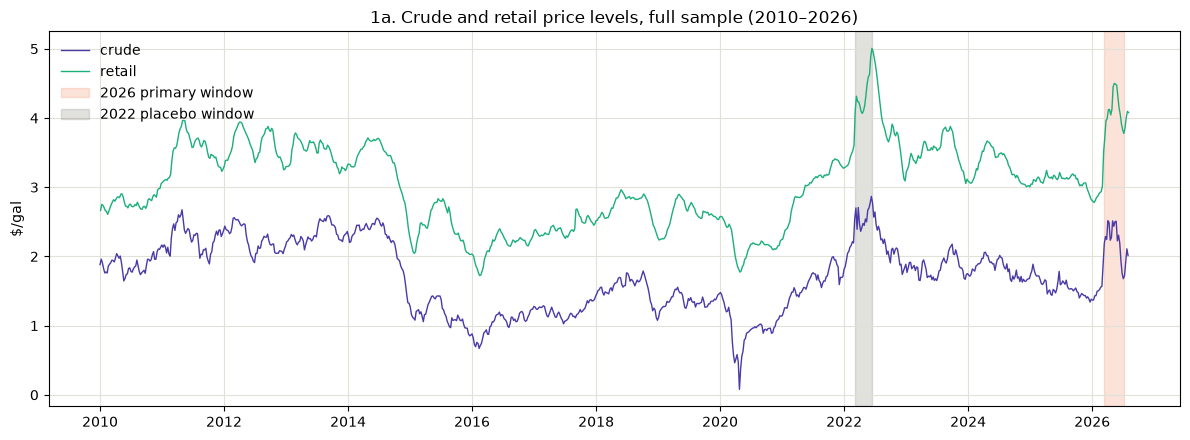

In [2]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(weekly_crude["date"], weekly_crude["value"], color=COLOR_CRUDE, linewidth=1.0, label="crude")
ax.plot(retail["date"], retail["value"], color=COLOR_RETAIL, linewidth=1.0, label="retail")

ax.axvspan(pd.Timestamp(PRIMARY_START), pd.Timestamp(PRIMARY_END), color=COLOR_PRIMARY_WINDOW, alpha=0.18, label="2026 primary window")
ax.axvspan(pd.Timestamp(PLACEBO_START), pd.Timestamp(PLACEBO_END), color=COLOR_PLACEBO_WINDOW, alpha=0.25, label="2022 placebo window")

ax.set_ylabel("$/gal")
ax.set_title("1a. Crude and retail price levels, full sample (2010–2026)")
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

2026 stands out against sixteen years of ordinary variation; §2a quantifies it.

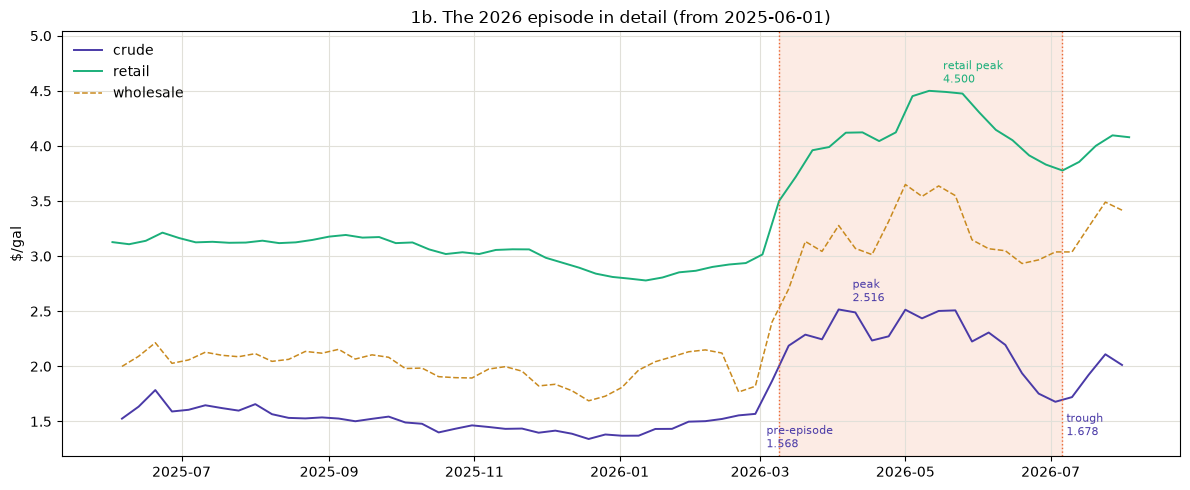

In [3]:
zoom_start = pd.Timestamp("2025-06-01")
crude_zoom = weekly_crude[weekly_crude["date"] >= zoom_start]
retail_zoom = retail[retail["date"] >= zoom_start]
wholesale_zoom = wholesale[wholesale["date"] >= zoom_start]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(crude_zoom["date"], crude_zoom["value"], color=COLOR_CRUDE, linewidth=1.4, label="crude")
ax.plot(retail_zoom["date"], retail_zoom["value"], color=COLOR_RETAIL, linewidth=1.4, label="retail")
ax.plot(wholesale_zoom["date"], wholesale_zoom["value"], color=COLOR_WHOLESALE, linewidth=1.1, linestyle="--", label="wholesale")

ax.axvspan(pd.Timestamp(PRIMARY_START), pd.Timestamp(PRIMARY_END), color=COLOR_PRIMARY_WINDOW, alpha=0.13)
for boundary in (pd.Timestamp(PRIMARY_START), pd.Timestamp(PRIMARY_END)):
    ax.axvline(boundary, color=COLOR_PRIMARY_WINDOW, linewidth=1, linestyle=":")

ax.set_ylim(top=max(crude_zoom["value"].max(), retail_zoom["value"].max(), wholesale_zoom["value"].max()) * 1.12)

annotations = [
    ("2026-02-27", 1.568, "pre-episode\n1.568", (8, -24), COLOR_CRUDE),
    ("2026-04-03", 2.516, "peak\n2.516", (10, 6), COLOR_CRUDE),
    ("2026-07-03", 1.678, "trough\n1.678", (8, -24), COLOR_CRUDE),
    ("2026-05-11", 4.500, "retail peak\n4.500", (10, 6), COLOR_RETAIL),
]
for date, value, text, offset, color in annotations:
    ax.annotate(text, xy=(pd.Timestamp(date), value), xytext=offset, textcoords="offset points", color=color, fontsize=8, ha="left")

ax.set_ylabel("$/gal")
ax.set_title("1b. The 2026 episode in detail (from 2025-06-01)")
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

Retail lags crude by a couple of weeks and does not fully match its swing: `05` found retail
passes through roughly 60-70% of a crude move in the first week, rising toward near-complete
pass-through by about the fourth week.

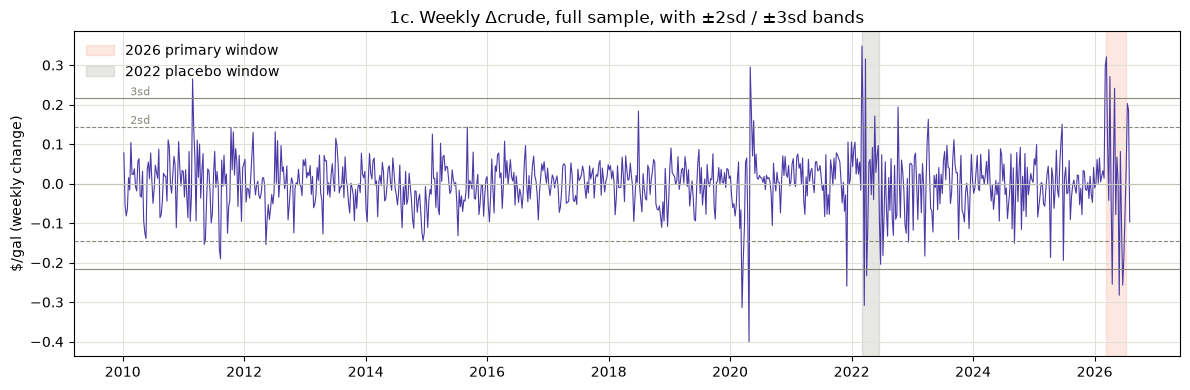

In [4]:
d_crude_full = weekly_crude["value"].diff()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly_crude["date"], d_crude_full, color=COLOR_CRUDE, linewidth=0.8)
ax.axhline(0, color="#c3c2b7", linewidth=0.8)

for mult, ls in [(2, "--"), (3, "-")]:
    ax.axhline(mult * sd_dcrude, color="#8a887c", linewidth=0.8, linestyle=ls)
    ax.axhline(-mult * sd_dcrude, color="#8a887c", linewidth=0.8, linestyle=ls)
label_x = weekly_crude["date"].iloc[3]
ax.text(label_x, 2 * sd_dcrude, " 2sd", fontsize=8, color="#8a887c", va="bottom")
ax.text(label_x, 3 * sd_dcrude, " 3sd", fontsize=8, color="#8a887c", va="bottom")

ax.axvspan(pd.Timestamp(PRIMARY_START), pd.Timestamp(PRIMARY_END), color=COLOR_PRIMARY_WINDOW, alpha=0.15, label="2026 primary window")
ax.axvspan(pd.Timestamp(PLACEBO_START), pd.Timestamp(PLACEBO_END), color=COLOR_PLACEBO_WINDOW, alpha=0.2, label="2022 placebo window")

ax.set_title("1c. Weekly Δcrude, full sample, with ±2sd / ±3sd bands")
ax.set_ylabel("$/gal (weekly change)")
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

Crude crosses the 3sd line more often in the 2026 window (7 weeks) than in 2022 (4) or 2020 (3);
2020's single largest move (−5.54sd, 2020-04-24) is still the most extreme week in the sample.
§2a counts the crossings.

## 2. Which weeks, exactly?

**2a.** Every week in the sample with |Δcrude| > 3sd, grouped into episodes by date: a new
episode starts whenever a >3sd week falls more than 60 days after the previous one. The widest
gap inside a single episode is 28 days (2026); the narrowest gap between two separate episodes is
91 days (an isolated week in December 2021, and the March 2022 cluster) — 60 days sits between
both.

In [5]:
d = weekly_crude["value"].diff()
sd_units = d / sd_dcrude

beyond3 = weekly_crude.loc[sd_units.abs() > 3, ["date", "value"]].copy()
beyond3["d_crude"] = d[sd_units.abs() > 3]
beyond3["sd_units"] = sd_units[sd_units.abs() > 3]
beyond3 = beyond3.sort_values("date").reset_index(drop=True)

gap = beyond3["date"].diff()
new_episode = gap.isna() | (gap > pd.Timedelta(days=60))
episode_num = new_episode.cumsum()
beyond3["episode"] = episode_num.map(beyond3.groupby(episode_num)["date"].min().dt.year.astype(str))

print(beyond3.groupby("episode").size().rename("n_weeks_beyond_3sd"))
print()
beyond3.round({"value": 4, "d_crude": 4, "sd_units": 4})

episode
2011    1
2020    3
2021    1
2022    4
2026    7
Name: n_weeks_beyond_3sd, dtype: int64



,date,value,d_crude,sd_units,episode
0,2011-02-25,2.2681,0.2650,3.6676,2011
1,2020-03-13,0.7712,-0.3138,-4.3431,2020
2,2020-04-24,0.0790,-0.4000,-5.5360,2020
3,2020-05-01,0.3740,0.2950,4.0828,2020
4,2021-12-03,1.5926,-0.2595,-3.5918,2021
5,2022-03-04,2.5429,0.3481,4.8177,2022
6,2022-03-18,2.3912,-0.3086,-4.2706,2022
7,2022-03-25,2.7069,0.3157,4.3695,2022
8,2022-04-01,2.4736,-0.2333,-3.2293,2022
9,2026-03-06,1.8660,0.2976,4.1191,2026


**2b.** Candidate windows, including the ones not chosen, compared by `n_weeks`, `n_up`,
`n_down`, and mean move size.

In [6]:
def candidate_window_stats(retail_start, retail_end) -> dict:
    crude_start = pd.Timestamp(retail_start) - pd.Timedelta(days=3)
    crude_end = pd.Timestamp(retail_end) - pd.Timedelta(days=3)
    window = weekly_crude[(weekly_crude["date"] >= crude_start) & (weekly_crude["date"] <= crude_end)]
    window_d = d.loc[window.index]
    return {
        "n_weeks": len(window),
        "n_up": int((window_d > 0).sum()),
        "n_down": int((window_d < 0).sum()),
        "mean_abs_dcrude": window_d.abs().mean(),
        "mean_abs_in_sd_units": window_d.abs().mean() / sd_dcrude,
    }


candidates = [
    ("rise-only", "2026-03-09", "2026-04-06"),
    ("round-trip (chosen)", "2026-03-09", "2026-07-06"),
    ("through-end-of-data", "2026-03-09", "2026-08-03"),
    ("2022 placebo", "2022-03-07", "2022-06-13"),
]

candidate_table = pd.DataFrame(
    [{"candidate": name, "retail_start": start, "retail_end": end, **candidate_window_stats(start, end)} for name, start, end in candidates]
)
candidate_table.round(4)

,candidate,retail_start,retail_end,n_weeks,n_up,n_down,mean_abs_dcrude,mean_abs_in_sd_units
0,rise-only,2026-03-09,2026-04-06,5,4,1,0.2065,2.8576
1,round-trip (chosen),2026-03-09,2026-07-06,18,9,9,0.1520,2.1040
2,through-end-of-data,2026-03-09,2026-08-03,22,12,10,0.1484,2.0535
3,2022 placebo,2022-03-07,2022-06-13,15,10,5,0.1410,1.9519


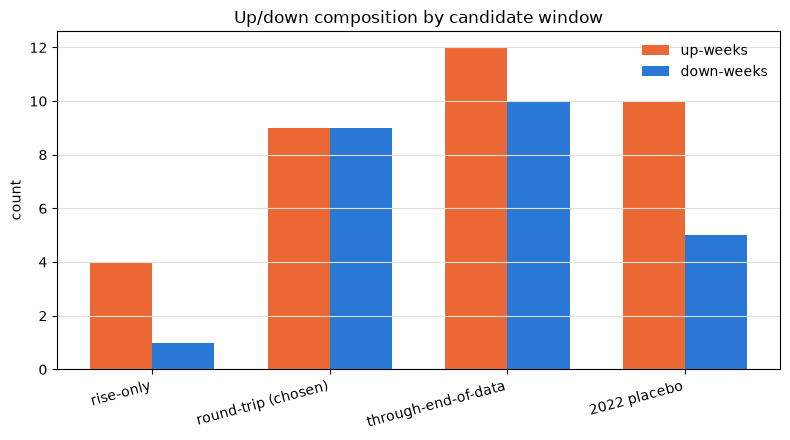

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(candidate_table))
width = 0.35

ax.bar(x - width / 2, candidate_table["n_up"], width, color=COLOR_UP, label="up-weeks")
ax.bar(x + width / 2, candidate_table["n_down"], width, color=COLOR_DOWN, label="down-weeks")

ax.set_xticks(x)
ax.set_xticklabels(candidate_table["candidate"], rotation=15, ha="right")
ax.set_ylabel("count")
ax.set_title("Up/down composition by candidate window")
ax.grid(True, axis="y", color="#e1e0d9")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

**2c.** Chosen window: retail Mondays `2026-03-09` to `2026-07-06`, 18 weeks, 9 up / 9 down.

2026 is the only complete round trip among the sample's large episodes. Crude ran 1.568 before
the window, up to 2.516 at the peak, down to 1.678 by the window's end, an 88% retracement of the
rise. Retail moved in the same direction but retraced only about half its rise (peak 4.500, down
to 3.777 by the window's end, a 49% retracement), before a separate, unresolved climb begins in
mid-July (crude +0.203, +0.186 over the following two weeks; the sample ends 2026-07-31). Neither
placebo episode completes a round trip: 2022 rises from 2.195 to a window-end value of 2.867, its
own high point, never reversing. 2020 crashes from 1.085 to 0.079 and recovers only to 0.902 by
the window's end, again its own high point within the window, and still well below the pre-crash
level. Both placebos end at their peak; only 2026 ends near where it started.

2026 also has the most 3sd weeks in the sample (7, against 4 for 2022 and 3 for 2020), though not
the largest single move: 2020's -5.54sd week (2020-04-24) is the sample's most extreme. And it is
the only balanced window, 9 up / 9 down, against 10/5 for 2022 and 9/5 for 2020, both skewed
toward up-weeks.

That balance is what rules out the alternatives in the table above. Rise-only has one down-week,
not enough to identify a down-side effect on its own. Through-end-of-data adds four weeks but
worsens the balance and ends at an arbitrary point: wherever the data happened to be pulled, not
wherever the episode ended. A later pull would move the boundary and change the result for no
substantive reason.

## 3. The interaction design

`build_event_interaction_design` adds an event marker to `05`'s up/down design and multiplies it
into each lag, so one regression estimates both the ordinary response and how far the 2026 weeks
departed from it.

Two versions, differing in how much freedom the event is given.

Spec A interacts every lag 0–4: ten extra parameters drawn from eighteen event weeks (5 lags x 2 deltas up and down).
Spec A has a separate coefficient at every lag, so if 2026's response arrived later than usual — say, mostly showing up in weeks 3-4 instead of weeks 0-1 — Spec A can see that shift. Spec B can't: it only has coefficients for lags 0-1, so a delayed response wouldn't show up anywhere in it.

Spec B interacts lags 0 and 1 only: four parameters, or 4.5 event weeks each against Spec A's
1.8. `05` placed the asymmetry there — significant at h=0 and h=1, indistinguishable from zero
from h=2 on — so this restricts the event effect to where the effect being tested actually lives.
If the event actually changed something at lag 2, 3, or 4, Spec B has no coefficient there to catch it — that effect would just get folded into the normal (non-event) lag 2-4 coefficients instead, and look like nothing happened.

The restriction comes from `05`, fitted before this model, rather than from inspecting these
results and keeping the lags that looked best. It is not independent evidence: `05` used the full
sample, event weeks included.

In [8]:
with _quiet():
    design_a = build_event_interaction_design(
        retail, weekly_crude, K=K, event_start=PRIMARY_START, event_end=PRIMARY_END, interact_lags=list(range(K + 1))
    )
    design_b = build_event_interaction_design(
        retail, weekly_crude, K=K, event_start=PRIMARY_START, event_end=PRIMARY_END, interact_lags=[0, 1]
    )

In [9]:
# Placebo design matrices are computed here, not deferred to §8, so this table can report both
# windows' condition numbers together -- the placebo test itself still doesn't run until §8.
with _quiet():
    design_a_placebo = build_event_interaction_design(
        retail, weekly_crude, K=K, event_start=PLACEBO_START, event_end=PLACEBO_END, interact_lags=list(range(K + 1))
    )
    design_b_placebo = build_event_interaction_design(
        retail, weekly_crude, K=K, event_start=PLACEBO_START, event_end=PLACEBO_END, interact_lags=[0, 1]
    )

In [10]:
def check_event_design(design: pd.DataFrame, interact_lags: list[int]) -> None:
    event = design["event"]
    for k in interact_lags:
        event_lag = event.shift(k).fillna(0)
        up_col, down_col = f"d_up_lag{k}_event", f"d_down_lag{k}_event"

        outside = event_lag == 0
        assert (design.loc[outside, up_col] == 0).all() and (design.loc[outside, down_col] == 0).all()

        raw_delta_lag_k = design[f"d_up_lag{k}"] + design[f"d_down_lag{k}"]
        identity_lhs = design[up_col] + design[down_col]
        identity_rhs = raw_delta_lag_k * event_lag
        assert (identity_lhs - identity_rhs).abs().max() < 1e-10

        assert (design[up_col] != 0).any() or (design[down_col] != 0).any()


def condition_number(design: pd.DataFrame) -> float:
    regressor_columns = [c for c in design.columns if c not in ("date", "d_retail")]
    X = np.column_stack([np.ones(len(design)), design[regressor_columns].to_numpy()])
    return float(np.linalg.cond(X))


check_event_design(design_a, list(range(K + 1)))
check_event_design(design_b, [0, 1])
check_event_design(design_a_placebo, list(range(K + 1)))
check_event_design(design_b_placebo, [0, 1])

In [11]:
def summarize_design(design: pd.DataFrame, window: str, spec: str) -> dict:
    n_up = int(((design["event"] == 1) & (design["d_up_lag0"] > 0)).sum())
    n_down = int(((design["event"] == 1) & (design["d_down_lag0"] < 0)).sum())
    return {
        "window": window,
        "spec": spec,
        "n_rows": len(design),
        "event_rows": int(design["event"].sum()),
        "up": n_up,
        "down": n_down,
        "condition_number": condition_number(design),
    }


summary_table = pd.DataFrame(
    [
        summarize_design(design_a, "2026", "A"),
        summarize_design(design_b, "2026", "B"),
        summarize_design(design_a_placebo, "2022 placebo", "A"),
        summarize_design(design_b_placebo, "2022 placebo", "B"),
    ]
)
summary_table.round(1)

,window,spec,n_rows,event_rows,up,down,condition_number
0,2026,A,861,18,9,9,167.4
1,2026,B,861,18,9,9,127.5
2,2022 placebo,A,861,15,10,5,330.3
3,2022 placebo,B,861,15,10,5,131.6


Spec A's estimates will be shakier in some windows than others, its condition number roughly doubles between windows (167 →
330). Spec B's condition number barely moves (128 → 132).

## 4. The fitted models

Both specs are fit on the full sample:

```
Δretail = α + γ·event + Σβ⁺·d_up_lag{k} + Σδ⁺·d_up_lag{k}_event
        + Σβ⁻·d_down_lag{k} + Σδ⁻·d_down_lag{k}_event + ε
```
with `maxlags=6` are unchanged from `05` and `06`.

Every week except the 18 in the 2026 window feeds into the 'normal' up-response and down-response coefficients, the everyday pattern. The 18 event weeks get their own extra coefficients on top ('how much different was 2026'). Both sets are fit together, in the same regression, on the full 861-week sample not the window alone because 'how different was 2026' only means something if there's a normal baseline in the same model to compare it against.

In [12]:
res_a = fit_distributed_lag(design_a, maxlags=DEFAULT_HAC_MAXLAGS)
res_b = fit_distributed_lag(design_b, maxlags=DEFAULT_HAC_MAXLAGS)

assert "event" in res_a.params.index and "event" in res_b.params.index

print(res_b.summary())

                            OLS Regression Results                            
Dep. Variable:               d_retail   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     28.35
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           8.71e-65
Time:                        17:21:39   Log-Likelihood:                 1500.5
No. Observations:                 861   AIC:                            -2969.
Df Residuals:                     845   BIC:                            -2893.
Df Model:                          15                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0028      0.00

Spec A tries to estimate 10 separate 2026-specific numbers, but only has 18 event weeks of data to estimate them from — less than 2 weeks of data per number. With that little data per coefficient, individual estimates bounce around a lot, so even if one of them shows a low p-value, that's more likely noise than a real finding. Look at the coefficients as a group (the joint test below) rather than trusting any single one.

In [13]:
print(res_a.summary())

                            OLS Regression Results                            
Dep. Variable:               d_retail   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     62.96
Date:                Thu, 20 Aug 2026   Prob (F-statistic):          3.19e-156
Time:                        17:21:39   Log-Likelihood:                 1514.4
No. Observations:                 861   AIC:                            -2985.
Df Residuals:                     839   BIC:                            -2880.
Df Model:                          21                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0028      0.00

How much noisier the 2026-specific estimates are than the normal ones, per lag:

In [14]:
def se_ratio_table(res, interact_lags, spec_label):
    rows = []
    for k in interact_lags:
        for direction in ("up", "down"):
            beta_name = f"d_{direction}_lag{k}"
            delta_name = f"d_{direction}_lag{k}_event"
            rows.append(
                {
                    "spec": spec_label,
                    "lag": k,
                    "direction": direction,
                    "beta_se": res.bse[beta_name],
                    "delta_se": res.bse[delta_name],
                    "ratio": res.bse[delta_name] / res.bse[beta_name],
                }
            )
    return pd.DataFrame(rows)


se_table = pd.concat([se_ratio_table(res_a, list(range(K + 1)), "A"), se_ratio_table(res_b, [0, 1], "B")], ignore_index=True)
se_table.round(3)

,spec,lag,direction,beta_se,delta_se,ratio
0,A,0,up,0.087,0.304,3.473
1,A,0,down,0.049,0.456,9.354
2,A,1,up,0.036,0.343,9.627
3,A,1,down,0.039,0.243,6.149
4,A,2,up,0.043,0.092,2.150
5,A,2,down,0.035,0.149,4.298
6,A,3,up,0.047,0.287,6.106
7,A,3,down,0.032,0.113,3.535
8,A,4,up,0.040,0.097,2.414
9,A,4,down,0.044,0.180,4.048


The 2026-specific coefficients have standard errors 2 to 10 times wider than the normal, everyday coefficients — about 5x wider on average for Spec A, 4.5x for Spec B. That's just sample size: the normal coefficients are estimated from roughly 840 weeks, the 2026-specific ones from only 18. This is exactly why Spec B — which estimates fewer 2026-specific numbers (4 instead of 10) — is worth having alongside Spec A: fewer numbers means each one gets more of those 18 weeks behind it, so they're somewhat less noisy.

The normal, everyday coefficients barely move whether or not 2026 gets pulled out separately: same-week up-response is 0.696 in `05` versus 0.623–0.636 here, down-response 0.263 versus 0.260. The small shift is simply because those 18 weeks stop contributing to the 'normal' estimate once they get their own coefficients instead.

## 5. Did 2026 behave differently?

Given the fitted regression, does the evidence support "2026 responded differently than normal weeks"? Specifically two sub-questions: (a) did anything about the 2026 response differ from normal (the joint test), and (b) is the gap between up-response and down-response widen or narrow during 2026 (the asymmetry-change test).

In [15]:
def t_stat(estimate, se):
    return estimate / se if se else float("nan")


def display_with_pvalue(df, col="p_value", threshold=0.0001):
    """round(4) turns any p-value smaller than 0.0001 into a misleading literal 0.0000.
    Anything that small is shown as '<0.0001' instead of being rounded away."""
    out = df.round(4).copy()
    out[col] = df[col].apply(lambda p: (f"<{threshold}" if pd.notna(p) and p < threshold else (f"{p:.4f}" if pd.notna(p) else "")))
    return out


test_rows = []
for spec_label, res in [("A", res_a), ("B", res_b)]:
    joint = test_event_interaction_joint(res)
    test_rows.append(
        {
            "spec": spec_label,
            "test": "joint F",
            "statistic": joint["f_stat"],
            "p_value": joint["p_value"],
            "estimate": float("nan"),
            "ci_lo": float("nan"),
            "ci_hi": float("nan"),
        }
    )
    asym = test_event_asymmetry_change(res)
    test_rows.append(
        {
            "spec": spec_label,
            "test": "asymmetry change",
            "statistic": t_stat(asym["estimate"], asym["se"]),
            "p_value": asym["p_value"],
            "estimate": asym["estimate"],
            "ci_lo": asym["ci_lo"],
            "ci_hi": asym["ci_hi"],
        }
    )

test_table = pd.DataFrame(test_rows)
display_with_pvalue(test_table)

,spec,test,statistic,p_value,estimate,ci_lo,ci_hi
0,A,joint F,12.4572,<0.0001,NaN,NaN,NaN
1,A,asymmetry change,0.1721,0.8633,0.2795,-2.9030,3.4620
2,B,joint F,2.8687,0.0223,NaN,NaN,NaN
3,B,asymmetry change,0.2428,0.8081,0.1614,-1.1416,1.4645


The up-versus-down gap did not move during the event: the asymmetry-change estimate is close
to zero for both specs (0.280 for Spec A, p=0.863; 0.161 for Spec B, p=0.808). The joint test
asks a different question: does any of the 2026-specific numbers differ from zero, all at once.
That one does reject for both specs (p<0.0001 for A, p=0.022 for B), so at least one
2026-specific coefficient looks nonzero, even though the up-versus-down gap itself does not.
Which coefficient, and whether that's a real pattern or noise, is what the individual numbers
below check.

Both specs' joint test comes back significant, so the individual 2026-specific coefficients are shown below as follow-up detail — not as standalone findings, since the joint test doesn't say which coefficient drove the result.

In [16]:
def delta_table(res, interact_lags, spec_label):
    rows = []
    for k in interact_lags:
        for direction in ("up", "down"):
            name = f"d_{direction}_lag{k}_event"
            rows.append({"spec": spec_label, "lag": k, "direction": direction, "coef": res.params[name], "se": res.bse[name], "p_value": res.pvalues[name]})
    return pd.DataFrame(rows)


posthoc_table = pd.concat([delta_table(res_a, list(range(K + 1)), "A"), delta_table(res_b, [0, 1], "B")], ignore_index=True)
display_with_pvalue(posthoc_table)

,spec,lag,direction,coef,se,p_value
0,A,0,up,0.3600,0.3036,0.2357
1,A,0,down,0.2551,0.4556,0.5755
2,A,1,up,-0.1247,0.3429,0.7161
3,A,1,down,0.0055,0.2425,0.9818
4,A,2,up,0.0521,0.0923,0.5724
5,A,2,down,-0.3619,0.1486,0.0149
6,A,3,up,-0.0705,0.2870,0.8060
7,A,3,down,-0.2353,0.1128,0.0371
8,A,4,up,-0.2617,0.0969,0.0069
9,A,4,down,0.0123,0.1798,0.9455


Spec A's 10 individual coefficients, 3 happen to cross p<0.05 on their own (lag2-down, lag3-down, lag4-up) — but they don't move in the same direction or tell a consistent economic story (a real effect would plausibly show the same sign across nearby lags). That's the signature of noise scattered across many correlated, poorly-estimated coefficients, precisely what the joint test is built to flag as "something," without endorsing any one of those hits as real. Spec B, with fewer and better-estimated coefficients, shows zero individual hits at all. The joint test says something differs somewhere, but neither the asymmetry-change test nor a coherent pattern among individual coefficients backs that up. So the section's conclusion is that 2026 does not show good evidence of the up-vs-down asymmetry changing, and the joint test's significance is best read as noise from a model with many correlated event-only coefficients, not a real effect.

## 6. Cumulative pass-through, normal versus event

If the event line pulled further away from the normal line, that would mean the up-vs-down gap widened under 2026's stress. If the lines moved closer together, that would mean pass-through became more symmetric. Here, the shaded bands overlap across the whole horizon in both panels — consistent with §5's finding that the asymmetry-change estimate was close to zero.

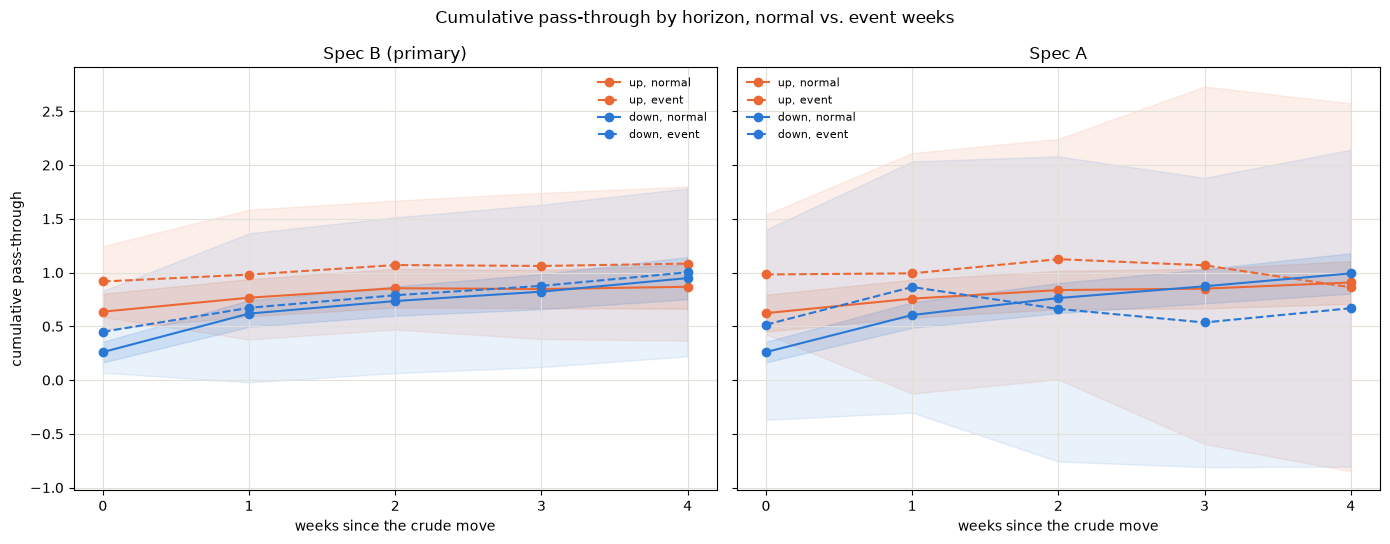

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, res, title in zip(axes, [res_b, res_a], ["Spec B (primary)", "Spec A"]):
    cum = cumulative_passthrough_by_regime(res, K)

    ax.plot(cum["horizon"], cum["cum_up_normal"], color=COLOR_UP, linestyle="-", marker="o", label="up, normal")
    ax.fill_between(cum["horizon"], cum["cum_up_normal_lo"], cum["cum_up_normal_hi"], color=COLOR_UP, alpha=0.15)
    ax.plot(cum["horizon"], cum["cum_up_event"], color=COLOR_UP, linestyle="--", marker="o", label="up, event")
    ax.fill_between(cum["horizon"], cum["cum_up_event_lo"], cum["cum_up_event_hi"], color=COLOR_UP, alpha=0.1)

    ax.plot(cum["horizon"], cum["cum_down_normal"], color=COLOR_DOWN, linestyle="-", marker="o", label="down, normal")
    ax.fill_between(cum["horizon"], cum["cum_down_normal_lo"], cum["cum_down_normal_hi"], color=COLOR_DOWN, alpha=0.15)
    ax.plot(cum["horizon"], cum["cum_down_event"], color=COLOR_DOWN, linestyle="--", marker="o", label="down, event")
    ax.fill_between(cum["horizon"], cum["cum_down_event_lo"], cum["cum_down_event_hi"], color=COLOR_DOWN, alpha=0.1)

    ax.set_title(title)
    ax.set_xlabel("weeks since the crude move")
    ax.set_xticks(cum["horizon"])
    ax.grid(True, color="#e1e0d9")
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel("cumulative pass-through")
fig.suptitle("Cumulative pass-through by horizon, normal vs. event weeks")
plt.tight_layout()
plt.show()

Bands overlap across the whole horizon in both panels, for both up and down, consistent with
§5's asymmetry-change estimate being close to zero. In Spec B, the event and normal lines merge
exactly at h=1, since Spec B has no 2026-specific coefficient past lag 1 (see §3).

## 7. Placebo windows

2026's crude moves were among the largest in the sample. This section checks whether that size
alone, not anything specific to 2026, explains what §5 found, by rerunning the identical
test on two other large-move episodes (placebo).

Both windows are chosen the same way 2026's was, bracketing a cluster of >3sd weeks.

| window | dates | reason |
|---|---|---|
| 2022 (primary) | `2022-03-07`-`2022-06-13` | Closest structural twin: geopolitical supply shock, 4 weeks beyond 3sd, moves both directions. |
| 2020 (secondary) | `2020-03-16`-`2020-06-15` | Includes the sample's single most extreme week (2020-04-24, -5.54sd). Kept in on purpose, as an upper bound on how large an effect can look in a disrupted market. But COVID also collapsed retail demand here, so a result may reflect that instead of pricing behavior. |

2011 excluded: one week beyond 3sd, too small to form a window.

Both placebos have fewer down-weeks than 2026's 9/9 split: 2022 has 10 up-weeks and only 5
down-weeks, 2020 has 9 up and 5 down. Fewer down-weeks means the model has less data to pin down
the down-side response in those windows, so its estimate there is less precise than 2026's.

That matters for how a null result gets read. If a window's confidence interval in §7b includes
zero, that can mean the gap really didn't change, or it can mean the test didn't have enough
data to detect a change that was actually there. With only 5 down-weeks, the second explanation
is live for 2022 and 2020 in a way it isn't for 2026. So a null result in either placebo should
be read as inconclusive, not as proof nothing changed. 2026 remains the only episode in the
sample with both a large rise and a large fall in one window.

In [18]:
PLACEBO_2020_START, PLACEBO_2020_END = "2020-03-16", "2020-06-15"

window_order = ["2026", "2022", "2020"]
windows = [
    ("2026", PRIMARY_START, PRIMARY_END),
    ("2022", PLACEBO_START, PLACEBO_END),
    ("2020", PLACEBO_2020_START, PLACEBO_2020_END),
]
specs = [("A", list(range(K + 1))), ("B", [0, 1])]

with _quiet():
    event_study_results = {
        (window_name, spec_name): run_event_study(
            retail,
            weekly_crude,
            K=K,
            event_start=start,
            event_end=end,
            label=f"{window_name}-{spec_name}",
            interact_lags=lags,
            maxlags=DEFAULT_HAC_MAXLAGS,
        )
        for window_name, start, end in windows
        for spec_name, lags in specs
    }

**7a.** Basic stats for each episode's crude moves, before any model is fit. `n_up`/`n_down`
here match §3/§4's table for 2026; this is the first time 2022 and 2020 get the same treatment.

In [19]:
def episode_window_stats(retail_start, retail_end, shape):
    crude_start = pd.Timestamp(retail_start) - pd.Timedelta(days=3)
    crude_end = pd.Timestamp(retail_end) - pd.Timedelta(days=3)
    window = weekly_crude[(weekly_crude["date"] >= crude_start) & (weekly_crude["date"] <= crude_end)]
    window_d = d.loc[window.index]
    window_sd = sd_units.loc[window.index]
    return {
        "n_weeks": len(window),
        "n_up": int((window_d > 0).sum()),
        "n_down": int((window_d < 0).sum()),
        "mean_abs_dcrude_sd": window_d.abs().mean() / sd_dcrude,
        "max_abs_dcrude_sd": window_sd.abs().max(),
        "n_weeks_beyond_3sd": int((window_sd.abs() > 3).sum()),
        "shape": shape,
    }


episode_stats = {
    "2026": episode_window_stats(PRIMARY_START, PRIMARY_END, "round trip"),
    "2022": episode_window_stats(PLACEBO_START, PLACEBO_END, "rise, no reversal"),
    "2020": episode_window_stats(PLACEBO_2020_START, PLACEBO_2020_END, "crash, partial recovery"),
}

episode_table = pd.DataFrame([{"window": name, **stats} for name, stats in episode_stats.items()])
episode_table.round(3)

,window,n_weeks,n_up,n_down,mean_abs_dcrude_sd,max_abs_dcrude_sd,n_weeks_beyond_3sd,shape
0,2026,18,9,9,2.104,4.442,7,round trip
1,2022,15,10,5,1.952,4.818,4,"rise, no reversal"
2,2020,14,9,5,2.042,5.536,3,"crash, partial recovery"


**7b.** The main result: for each window, the extra up-response minus the extra down-response
(`sum(delta+) - sum(delta-)` in §4's equation), with its 95% confidence interval. One panel per
spec.

The down-response half of that number comes from far fewer weeks in the placebos than in 2026:
9 down-weeks for 2026, only 5 for 2022 and 5 for 2020. Fewer weeks means a less precise
down-response estimate, which widens the combined confidence interval and makes it more likely
to cross zero even if a real change exists. A null result in 2022 or 2020 is therefore weaker
evidence of "nothing changed" than a null result in 2026 would be.

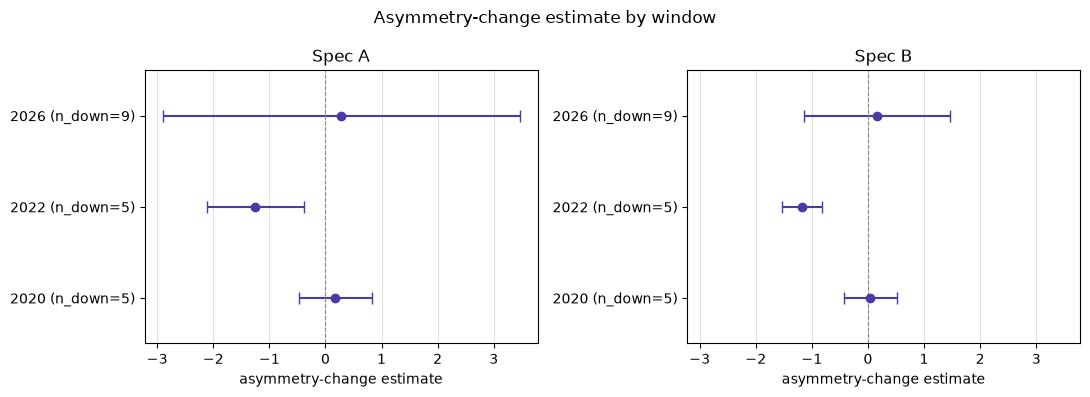

In [ ]:
down_n = episode_table.set_index("window")["n_down"].to_dict()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
fig.suptitle("Asymmetry-change estimate by window")

for ax, spec_name in zip(axes, ["A", "B"]):
    for y, wname in enumerate(window_order):
        result = event_study_results[(wname, spec_name)]["asymmetry_change"]
        ax.errorbar(
            result["estimate"],
            y,
            xerr=[[result["estimate"] - result["ci_lo"]], [result["ci_hi"] - result["estimate"]]],
            fmt="o",
            color=COLOR_CRUDE,
            capsize=4,
        )
    ax.axvline(0, color="#8a887c", linewidth=0.8, linestyle="--")
    ax.set_yticks(range(len(window_order)))
    ax.set_yticklabels([f"{w} (n_down={down_n[w]})" for w in window_order])
    ax.set_ylim(-0.5, len(window_order) - 0.5)
    ax.invert_yaxis()
    ax.set_title(f"Spec {spec_name}")
    ax.set_xlabel("asymmetry-change estimate")
    ax.grid(True, axis="x", color="#e1e0d9")

fig.suptitle("Asymmetry-change estimate by window")
plt.tight_layout()
plt.show()

In [21]:
asymmetry_change_table = pd.DataFrame(
    [
        {"window": wname, "spec": sname, **event_study_results[(wname, sname)]["asymmetry_change"]}
        for wname in window_order
        for sname in ["A", "B"]
    ]
)[["window", "spec", "estimate", "se", "ci_lo", "ci_hi", "p_value"]]
display_with_pvalue(asymmetry_change_table)

,window,spec,estimate,se,ci_lo,ci_hi,p_value
0,2026,A,0.2795,1.6237,-2.9030,3.4620,0.8633
1,2026,B,0.1614,0.6648,-1.1416,1.4645,0.8081
2,2022,A,-1.2493,0.4403,-2.1123,-0.3864,0.0045
3,2022,B,-1.1752,0.1819,-1.5317,-0.8187,<0.0001
4,2020,A,0.1744,0.3308,-0.4740,0.8228,0.5980
5,2020,B,0.0429,0.2438,-0.4348,0.5207,0.8602


2022's interval excludes zero in both specs (plot and table above). 2026's and 2020's both include zero. In 2022 the up-versus-down gap got smaller and pass-through became more symmetric that year.

This doesn't reverse `05`'s finding that prices rise faster than they fall on average across the full 16-year sample. That result doesn't depend on 2022 and isn't affected by it. This is a separate, narrower observation, 2022 alone deviated from the usual pattern, toward more symmetry. §7d checks whether that deviation is genuine or just noise from a short window with few weeks to estimate from.

**7c.** If a window behaved exactly like a normal week, its extra coefficients would all be
zero, that's the baseline the joint test checks against. Run separately for each window: does
the data still look consistent with that baseline, or not?

In [22]:
joint_table = pd.DataFrame(
    [
        {
            "window": wname,
            "spec": sname,
            "f_stat": event_study_results[(wname, sname)]["joint"]["f_stat"],
            "p_value": event_study_results[(wname, sname)]["joint"]["p_value"],
        }
        for wname in window_order
        for sname in ["A", "B"]
    ]
)
display_with_pvalue(joint_table)

,window,spec,f_stat,p_value
0,2026,A,12.4572,<0.0001
1,2026,B,2.8687,0.0223
2,2022,A,12.9408,<0.0001
3,2022,B,14.8608,<0.0001
4,2020,A,10.7820,<0.0001
5,2020,B,8.3328,<0.0001


The test says "not consistent with the baseline" for all three windows, both specs (p<0.03
everywhere). So it isn't only 2026 that looks different from a normal week here, 2022 and 2020
do too. The test may just be reacting to how much
crude's price swung that week, regardless of which year it happened in. This test can't rule that out, but it also can't rule out each window having its own separate reason.

**7d.** §7c can't tell whether a window's extra coefficients are a real, coherent pattern or
just noise, only that they're not all zero. This section checks that directly: for each window
and spec, how many individual coefficients have p<0.05, and do the ones that do point the same
way or scatter randomly?

This matters most for 2022. In §5, three of 2026's Spec A coefficients had p<0.05 (lag 2 down,
lag 3 down, lag 4 up), but they flipped sign between neighbouring lags with no consistent
story, and were read as noise rather than a real effect. If 2022's or 2020's coefficients
scatter the same way, that same judgement holds there too. If instead a window's coefficients
line up in a consistent direction, that's evidence of something real, not noise.

In [23]:
def delta_hits(res, lags):
    hits = []
    for k in lags:
        for direction in ("up", "down"):
            name = f"d_{direction}_lag{k}_event"
            if res.pvalues[name] < 0.05:
                p = res.pvalues[name]
                p_display = "<0.0001" if p < 0.0001 else round(p, 4)
                hits.append({"lag": k, "direction": direction, "coef": round(res.params[name], 4), "p_value": p_display})
    return hits


scatter_rows = []
hit_rows = []
for wname in window_order:
    for sname, lags in specs:
        res = event_study_results[(wname, sname)]["res"]
        hits = delta_hits(res, lags)
        scatter_rows.append({"window": wname, "spec": sname, "n_params": len(lags) * 2, "n_hits": len(hits)})
        for h in hits:
            hit_rows.append({"window": wname, "spec": sname, **h})

scatter_table = pd.DataFrame(scatter_rows)
scatter_table

,window,spec,n_params,n_hits
0,2026,A,10,3
1,2026,B,4,0
2,2022,A,10,3
3,2022,B,4,2
4,2020,A,10,5
5,2020,B,4,0


In [24]:
hits_table = pd.DataFrame(hit_rows, columns=["window", "spec", "lag", "direction", "coef", "p_value"])
hits_table.sort_values(by=["window", "spec", "lag", "direction"], ascending=[False, True, True, True]).reset_index(drop=True)

,window,spec,lag,direction,coef,p_value
0,2026,A,2,down,-0.3619,0.0149
1,2026,A,3,down,-0.2353,0.0371
2,2026,A,4,up,-0.2617,0.0069
3,2022,A,1,up,-0.2822,0.0005
4,2022,A,3,up,-0.5602,0.0080
5,2022,A,4,up,-0.2118,0.0441
6,2022,B,1,down,0.7585,0.0002
7,2022,B,1,up,-0.3435,0.0000
8,2020,A,0,down,-0.1962,0.0406
9,2020,A,0,up,-0.3174,0.0043


Spec A has p<0.05 on 3 of 10 numbers for 2026, 3 of 10 for 2022, and 5 of 10 for 2020. 2020
scatters more than 2026, not less, and the significant coefficients flip sign between
neighbouring lags in all three windows. That scatter looks like what ten parameters estimated
from fifteen-to-eighteen weeks produce on their own, not something particular to 2026.

Spec B is different for 2022. The result isn't scattered noise: both of its significant numbers hit at the same one-week delay, and both push the up-vs-down gap in the same direction. That is a real pattern, not random chance. 2026 and 2020 don't have this, Spec B finds nothing significant in either of them.

**7e.** Baseline check: each window's joint fit already produces a normal, non-event
up-response and down-response, estimated mainly from that window's non-event weeks, since the
event weeks get their own separate coefficients instead. Compare those normal numbers to `05`'s
original full-sample estimate.

In [25]:
baseline_rows = []
ref_up, ref_down = 0.6960, 0.2633  # 05's standalone K=4 estimate
for wname in window_order:
    for sname in ["A", "B"]:
        res = event_study_results[(wname, sname)]["res"]
        up = res.params["d_up_lag0"]
        down = res.params["d_down_lag0"]
        baseline_rows.append(
            {
                "window": wname,
                "spec": sname,
                "up_lag0": up,
                "delta_up": up - ref_up,
                "down_lag0": down,
                "delta_down": down - ref_down,
            }
        )

baseline_table = pd.DataFrame(baseline_rows)
baseline_table.round(4)

,window,spec,up_lag0,delta_up,down_lag0,delta_down
0,2026,A,0.6226,-0.0734,0.2603,-0.0030
1,2026,B,0.6363,-0.0597,0.2602,-0.0031
2,2022,A,0.6491,-0.0469,0.2579,-0.0054
3,2022,B,0.6483,-0.0477,0.2656,0.0023
4,2020,A,0.7000,0.0040,0.3021,0.0388
5,2020,B,0.6982,0.0022,0.3027,0.0394


The largest deviation from `05`'s up-response and down-response estimates, across all six
window/spec combinations, is 0.073 (2026 Spec A's up-response, see `delta_up` above). Every
other window sits closer than that. The check passes: if one window's own data had been
responsible for `05`'s up-response or down-response number, removing that window would shift
its baseline by a lot. None of them do, so no single window is carrying those two numbers on
its own.

**7f.** 2022's negative estimate needs two checks before it goes any further: is it being
driven by one week, and what does testing three windows instead of one mean for how confidently
to read it?

Spec B's 2022 result rests on 15 event weeks, 10 up and 5 down. The single largest move in that
window, 2022-03-07, a +0.35 $/gal crude jump, could be doing most of the work on its own. The
check: refit with that one week dropped from the full sample (the same influence check `05`
already applies to 2026) and see whether the estimate collapses toward zero.

In [26]:
with _quiet():
    design_2022_b = build_event_interaction_design(
        retail, weekly_crude, K=K, event_start=PLACEBO_START, event_end=PLACEBO_END, interact_lags=[0, 1]
    )

event_rows_2022 = design_2022_b[design_2022_b["event"] == 1].copy()
event_rows_2022["abs_move"] = (event_rows_2022["d_up_lag0"] + event_rows_2022["d_down_lag0"]).abs()
largest_move_date = event_rows_2022.sort_values("abs_move", ascending=False)["date"].iloc[0]

asym_2022_b_full = event_study_results[("2022", "B")]["asymmetry_change"]

design_2022_b_trimmed = design_2022_b[design_2022_b["date"] != largest_move_date].reset_index(drop=True)
res_2022_b_trimmed = fit_distributed_lag(design_2022_b_trimmed, maxlags=DEFAULT_HAC_MAXLAGS)
asym_2022_b_trimmed = test_event_asymmetry_change(res_2022_b_trimmed)

influence_table = pd.DataFrame(
    [
        {"fit": "all 15 event weeks", **asym_2022_b_full},
        {"fit": f"{largest_move_date.date()} excluded", **asym_2022_b_trimmed},
    ]
)
display_with_pvalue(influence_table)

,fit,estimate,se,ci_lo,ci_hi,p_value
0,all 15 event weeks,-1.1752,0.1819,-1.5317,-0.8187,<0.0001
1,2022-03-07 excluded,-1.4477,0.1834,-1.8072,-1.0882,<0.0001


The estimate moves from -1.175 (all 15 weeks, p<0.0001) to -1.448 (2022-03-07 excluded,
p<0.0001): further from zero, not toward it. One week isn't carrying this result; dropping the
largest mover makes the estimate larger, not smaller.

This result turned up in a control window, not the one the test was built for. Testing three windows instead of one gives more chances for a false positive to appear somewhere by chance, and 2022 is where it did. The influence check argues it isn't a fluke of the data, but it's still a finding the placebo design happened to surface, not one it set out to find, so it's reported as exploratory rather than confirmed.

## 8. Key findings

Two model variants are used below: Spec A gives each window its own separate coefficient at every lag (0-4 weeks after a crude move); Spec B restricts that to lags 0-1, where `05` found the up-versus-down gap concentrated (details in §3-4). Both test the same thing: did that window's gap between the up-response and the down-response change from normal.

**Did the 2026 spike change how prices responded to crude?** No. The up-versus-down gap itself shows no detectable change (asymmetry-change test: Spec A p=0.86, Spec B p=0.81). A different test, the joint test, which checks whether any of 2026's extra coefficients differ from zero, does reject (p<0.0001 Spec A, p=0.02 Spec B): three specific coefficients come back significant (2 weeks after a crude move, its response to a *drop* in crude; 3 weeks after, another drop; 4 weeks after, a *rise*). But §7d shows these three don't move in a consistent direction, an up-effect and two unrelated down-effects at different lags, and the same kind of scattered, inconsistent hits shows up in 2022 and 2020 too, not just 2026. That pattern is the signature of noise from too many coefficients estimated on too little data, not a real effect.

**Was 2026 itself different, or does any large crude move produce this?** The identical test was rerun on two comparison windows, 2022 and 2020, to check whether 2026 alone stands out or whether other large moves show the same thing. 2020 shows no change, same as 2026. 2022 shows a real change: the gap between the up-response and the down-response narrowed by $1.18 for every $1/gal that crude moved (Spec B: -1.175, p<0.0001), using the same $1/gal scaling unit used throughout this project, applied to a move in either direction, and by $1.45 (-1.448, still p<0.0001) when the window's single largest move is dropped, so this isn't one outlier week driving the result. Since only 2026 was this study's actual target, and 2022 and 2020 were included only as comparisons, testing three windows gave three chances for a result like this to appear by chance. The 2022 result is reported as exploratory, not confirmed evidence about 2026.

**Possible mechanism for 2022.** The gap narrowing means retail prices caught up faster than usual specifically on the *down* side, price decreases arrived closer to as-fast-as price increases than they normally do. One possible reason: the 2022 Russia-Ukraine conflict drew heavy, sustained media coverage of oil and gas prices, and that visibility may have encouraged retailers to pass price decreases through faster than usual.

**How big a change could this test have missed?** §7b's standard errors set a floor on what this design could detect; converting them to a minimum detectable effect (MDE) makes that floor explicit.

In [27]:
from scipy.stats import norm

# Minimum detectable effect (MDE): the smallest true gap-change this design could reliably
# catch at 80% power under the standard two-sided 5% significance threshold. Uses 2026's own
# standard errors from `asymmetry_change_table` (§7b) 
# converting an already-fitted regression's precision
power_factor = norm.ppf(0.975) + norm.ppf(0.80)  # ≈ 2.80

mde_2026 = asymmetry_change_table[asymmetry_change_table["window"] == "2026"].copy()
mde_2026["mde"] = power_factor * mde_2026["se"]
mde_2026[["spec", "se", "mde"]].round(3)

,spec,se,mde
0,A,1.624,4.549
1,B,0.665,1.863


**Limits of this analysis.** At 80% power and the standard two-sided 5% significance threshold, this design could only reliably detect a gap change of $1.86/gal (Spec B) to $4.55/gal (Spec A) per $1/gal of crude movement, computed above from 2026's own regression standard errors. For comparison, the project's headline same-week gap, estimated from all 16 years of data, is $0.43 (`05_asymmetry.ipynb` §8: a $1/gal crude increase moves retail by $0.70 within the same week versus $0.26 for a decrease), four to eleven times smaller than what this test could catch. With only 18 weeks of 2026 data to work with, a real effect anywhere in that range would look like ordinary week-to-week noise here.

Other caveats: the window stops before a second, unresolved climb in crude prices that was still underway when the data was pulled; 2020 is confounded by the COVID-19 demand collapse, which happened at the same time as that year's price crash; and gas taxes, seasonal fuel-blend changes, refinery outages, and ethanol content are not accounted for anywhere.